# Market Regime Detection: K-Means + Hidden Markov Model

**Project:** Uncertainty-Aware Financial Forecasting (COM0415 Applied Deep Learning)  
**Authors:** Lara Yıldırım, Belkıs Derin Yüksel

**Purpose:** Detect latent market regimes (e.g. bull/bear/volatile) using:
1. **K-Means** on log returns + rolling volatility → initial regime labels
2. **Hidden Markov Model (HMM)** → smooth, probabilistic regime sequence

Regimes will later be used as additional context for the Transformer's risk-aware strategy.

## Step 1: Install & Import

In [1]:
!pip install hmmlearn scikit-learn matplotlib pandas numpy --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 3.9 MB/s eta 0:00:00
Libraries loaded successfully.


## Step 2: Load Dataset

In [2]:
from google.colab import files
uploaded = files.upload()  # Upload financial_data.csv

df = pd.read_csv(list(uploaded.keys())[0], index_col=0, parse_dates=True).sort_index()

print(f'Dataset shape: {df.shape}')
print(f'Date range: {df.index.min().date()} to {df.index.max().date()}')
df.head()

Saving financial_data.csv to financial_data.csv
Dataset shape: (4231, 5)
Date range: 2010-01-04 to 2026-04-23


,BIST100_Close,SP500_Close,CPIAUCSL,FEDFUNDS,INDPRO
Date,,,,,
2010-01-04,533.679199,1132.989990,217.488,0.11,89.3426
2010-01-05,541.148132,1136.520020,217.488,0.11,89.3426
2010-01-06,545.471130,1137.140015,217.488,0.11,89.3426
2010-01-07,549.726074,1141.689941,217.488,0.11,89.3426
2010-01-08,547.976074,1144.979980,217.488,0.11,89.3426


## Step 3: Feature Engineering for Regime Detection

Following Haryani et al. (2026): use **log returns** + **rolling volatility** as regime features.

In [3]:
ROLL_VOL_WINDOW = 20  # 20-day rolling volatility

# Log returns
df['log_return'] = np.log(df['BIST100_Close'] / df['BIST100_Close'].shift(1))

# Rolling volatility (std of log returns)
df['rolling_vol'] = df['log_return'].rolling(ROLL_VOL_WINDOW).std()

# Drop NaNs from rolling window
regime_df = df[['log_return', 'rolling_vol']].dropna().copy()

print(f'Regime feature matrix shape: {regime_df.shape}')
print(f'Date range: {regime_df.index.min().date()} to {regime_df.index.max().date()}')
print()
print(regime_df.describe().round(6))

Regime feature matrix shape: (4211, 2)
Date range: 2010-02-01 to 2026-04-23

        log_return  rolling_vol
count  4211.000000  4211.000000
mean      0.000776     0.014153
std       0.015305     0.005708
min      -0.110637     0.005253
25%      -0.006806     0.010231
50%       0.000753     0.012952
75%       0.009250     0.016369
max       0.094234     0.039575


## Step 4: K-Means Clustering

Use K-Means with K=3 to identify initial regime labels:
- **Regime 0**: Low-vol, low-return (sideways/bear)
- **Regime 1**: High-vol (turbulent/crash)
- **Regime 2**: Positive-return, moderate-vol (bull)

In [4]:
N_REGIMES = 3

# Scale features before K-Means
scaler_km = StandardScaler()
X_km = scaler_km.fit_transform(regime_df[['log_return', 'rolling_vol']].values)

# K-Means
kmeans = KMeans(n_clusters=N_REGIMES, random_state=42, n_init=20)
km_labels = kmeans.fit_predict(X_km)
regime_df['kmeans_regime'] = km_labels

print('K-Means cluster centers (original scale):')
centers_original = scaler_km.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers_original, columns=['Mean Log Return', 'Mean Rolling Vol'])
print(centers_df.round(6))
print()
print('Regime counts:')
print(regime_df['kmeans_regime'].value_counts().sort_index())

K-Means cluster centers (original scale):
   Mean Log Return  Mean Rolling Vol
0        -0.017533          0.014838
1         0.005656          0.011656
2         0.010525          0.024700

Regime counts:
kmeans_regime
0    1002
1    2648
2     561
Name: count, dtype: int64


In [5]:
# Assign human-readable regime names based on cluster centers
# Sort clusters: by mean log return (ascending) → Bear, Sideways, Bull
order = np.argsort(centers_original[:, 0])  # sort by mean log return
label_map = {order[0]: 'Bear', order[1]: 'Sideways', order[2]: 'Bull'}
color_map = {'Bear': 'red', 'Sideways': 'gray', 'Bull': 'green'}

regime_df['regime_name'] = regime_df['kmeans_regime'].map(label_map)

print('Regime interpretation:')
for cluster_id, name in label_map.items():
    row = centers_original[cluster_id]
    count = (km_labels == cluster_id).sum()
    print(f'  Cluster {cluster_id} → {name:8s} | Mean Return: {row[0]:+.5f} | Mean Vol: {row[1]:.5f} | N={count}')

Regime interpretation:
  Cluster 0 → Bear     | Mean Return: -0.01753 | Mean Vol: 0.01484 | N=1002
  Cluster 1 → Sideways | Mean Return: +0.00566 | Mean Vol: 0.01166 | N=2648
  Cluster 2 → Bull     | Mean Return: +0.01053 | Mean Vol: 0.02470 | N=561


## Step 5: Hidden Markov Model

HMM refines the K-Means labels by learning **temporal regime transitions**.
Gaussian HMM with N=3 hidden states, initialized from K-Means.

Key outputs:
- **Viterbi sequence**: most probable regime at each day
- **Transition matrix**: probability of switching from one regime to another
- **Posterior probabilities**: soft regime assignment for each day

In [6]:
X_hmm = regime_df[['log_return', 'rolling_vol']].values

# Fit Gaussian HMM
hmm = GaussianHMM(
    n_components=N_REGIMES,
    covariance_type='full',
    n_iter=200,
    random_state=42,
    tol=1e-4,
)
hmm.fit(X_hmm)

# Viterbi decoding — most likely hidden state sequence
hmm_states = hmm.predict(X_hmm)
regime_df['hmm_state'] = hmm_states

# Posterior probabilities
posteriors = hmm.predict_proba(X_hmm)  # (n_days, N_REGIMES)

print(f'HMM converged. Log-likelihood: {hmm.score(X_hmm):.2f}')
print()
print('HMM Means per state:')
for i, mean in enumerate(hmm.means_):
    print(f'  State {i}: log_return={mean[0]:+.6f}, rolling_vol={mean[1]:.6f}')
print()
print('Transition Matrix:')
print(pd.DataFrame(hmm.transmat_.round(4),
                   index=[f'From {i}' for i in range(N_REGIMES)],
                   columns=[f'To {i}' for i in range(N_REGIMES)]))
print()
print('HMM state counts:')
print(pd.Series(hmm_states).value_counts().sort_index())

HMM converged. Log-likelihood: 29706.09

HMM Means per state:
  State 0: log_return=+0.000713, rolling_vol=0.011789
  State 1: log_return=+0.001392, rolling_vol=0.011821
  State 2: log_return=-0.000225, rolling_vol=0.022547

Transition Matrix:
          To 0    To 1    To 2
From 0  0.0012  0.9988  0.0000
From 1  0.9706  0.0115  0.0180
From 2  0.0194  0.0130  0.9675

HMM state counts:
0    1642
1    1648
2     921
Name: count, dtype: int64


In [7]:
# Assign regime names to HMM states (by mean log return)
hmm_order = np.argsort(hmm.means_[:, 0])  # sort by mean log return
hmm_label_map = {hmm_order[0]: 'Bear', hmm_order[1]: 'Sideways', hmm_order[2]: 'Bull'}
regime_df['hmm_regime'] = regime_df['hmm_state'].map(hmm_label_map)

print('HMM state interpretation:')
for state_id, name in hmm_label_map.items():
    mean = hmm.means_[state_id]
    count = (hmm_states == state_id).sum()
    print(f'  State {state_id} → {name:8s} | Mean Return: {mean[0]:+.6f} | Mean Vol: {mean[1]:.6f} | N={count}')

HMM state interpretation:
  State 2 → Bear     | Mean Return: -0.000225 | Mean Vol: 0.022547 | N=921
  State 0 → Sideways | Mean Return: +0.000713 | Mean Vol: 0.011789 | N=1642
  State 1 → Bull     | Mean Return: +0.001392 | Mean Vol: 0.011821 | N=1648


## Step 6: Visualizations

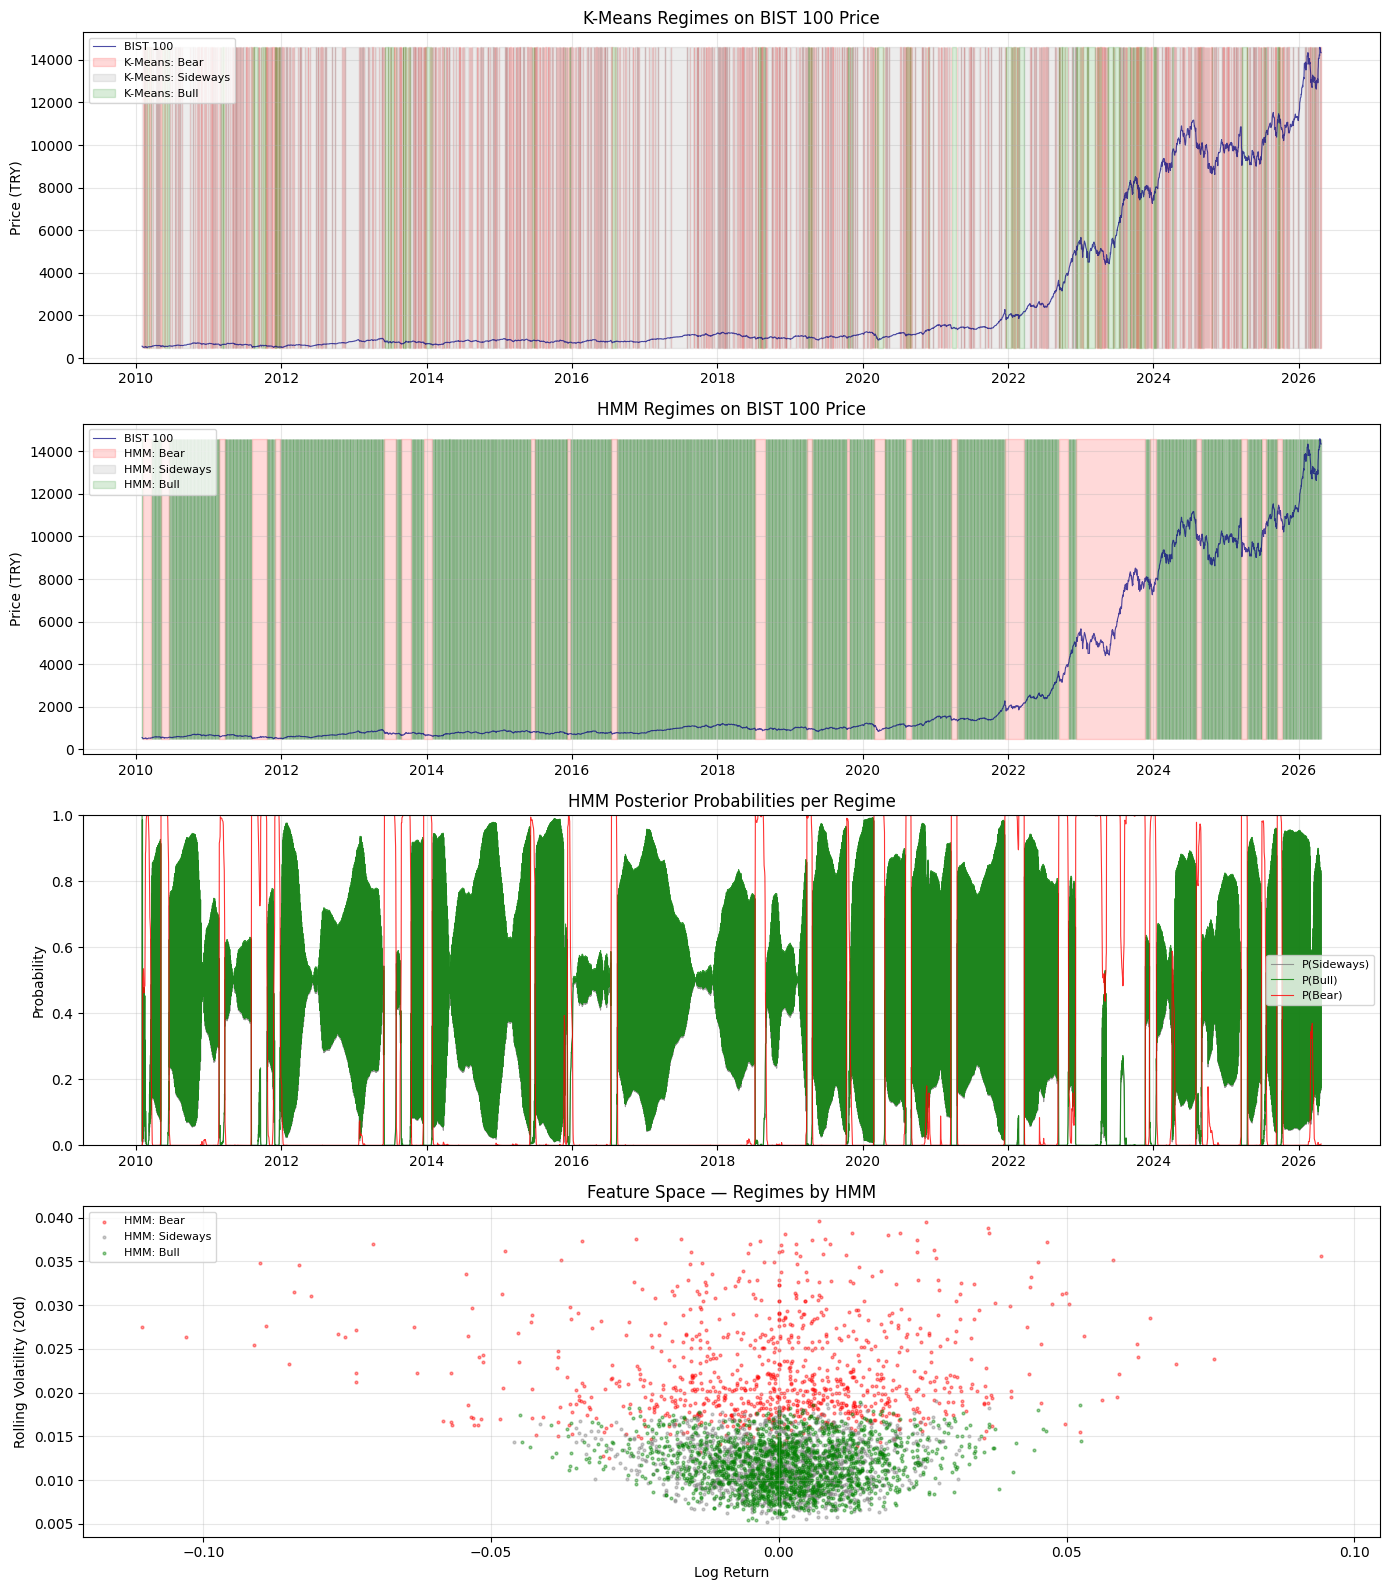

✅ Saved regime_detection_plot.png


In [8]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16))

bist_plot = df['BIST100_Close'].reindex(regime_df.index)
dates     = regime_df.index

# ---- Plot 1: K-Means regimes on BIST 100 price ----
ax = axes[0]
ax.plot(dates, bist_plot, color='navy', linewidth=0.8, alpha=0.7, label='BIST 100')
for regime_name, color in color_map.items():
    mask = regime_df['regime_name'] == regime_name
    ax.fill_between(dates, bist_plot.min(), bist_plot.max(),
                    where=mask, alpha=0.15, color=color, label=f'K-Means: {regime_name}')
ax.set_title('K-Means Regimes on BIST 100 Price')
ax.set_ylabel('Price (TRY)')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

# ---- Plot 2: HMM regimes on BIST 100 price ----
ax = axes[1]
ax.plot(dates, bist_plot, color='navy', linewidth=0.8, alpha=0.7, label='BIST 100')
for regime_name, color in color_map.items():
    mask = regime_df['hmm_regime'] == regime_name
    ax.fill_between(dates, bist_plot.min(), bist_plot.max(),
                    where=mask, alpha=0.15, color=color, label=f'HMM: {regime_name}')
ax.set_title('HMM Regimes on BIST 100 Price')
ax.set_ylabel('Price (TRY)')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

# ---- Plot 3: HMM posterior probabilities ----
ax = axes[2]
state_names = [hmm_label_map[i] for i in range(N_REGIMES)]
state_colors = [color_map[name] for name in state_names]
for i, (name, color) in enumerate(zip(state_names, state_colors)):
    ax.plot(dates, posteriors[:, i], label=f'P({name})', color=color, linewidth=0.8, alpha=0.8)
ax.set_title('HMM Posterior Probabilities per Regime')
ax.set_ylabel('Probability')
ax.set_ylim(0, 1)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ---- Plot 4: Feature space — K-Means vs HMM ----
ax = axes[3]
for regime_name, color in color_map.items():
    mask = regime_df['hmm_regime'] == regime_name
    ax.scatter(
        regime_df.loc[mask, 'log_return'],
        regime_df.loc[mask, 'rolling_vol'],
        c=color, s=4, alpha=0.4, label=f'HMM: {regime_name}'
    )
ax.set_xlabel('Log Return')
ax.set_ylabel('Rolling Volatility (20d)')
ax.set_title('Feature Space — Regimes by HMM')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('regime_detection_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved regime_detection_plot.png')

## Step 7: Regime Statistics

In [9]:
print('=== HMM Regime Statistics ===')
stats = regime_df.groupby('hmm_regime')['log_return'].agg(
    Count='count',
    Mean_Return='mean',
    Std_Return='std',
    Min_Return='min',
    Max_Return='max',
).round(6)
print(stats)
print()

# Regime transition statistics
print('=== HMM Transition Matrix (%) ===')
trans_pct = pd.DataFrame(
    (hmm.transmat_ * 100).round(2),
    index=[f'{hmm_label_map[i]}→' for i in range(N_REGIMES)],
    columns=[f'→{hmm_label_map[j]}' for j in range(N_REGIMES)]
)
print(trans_pct)

=== HMM Regime Statistics ===
            Count  Mean_Return  Std_Return  Min_Return  Max_Return
hmm_regime                                                        
Bear          921    -0.000151    0.023257   -0.110637    0.094234
Bull         1648     0.001587    0.013031   -0.044906    0.052551
Sideways     1642     0.000482    0.011226   -0.046027    0.036615

=== HMM Transition Matrix (%) ===
           →Sideways  →Bull  →Bear
Sideways→       0.12  99.88   0.00
Bull→          97.06   1.15   1.80
Bear→           1.94   1.30  96.75


## Step 8: Save Regime Labels

In [10]:
# Save full regime dataframe
output = regime_df[['log_return', 'rolling_vol', 'kmeans_regime', 'regime_name', 'hmm_state', 'hmm_regime']].copy()

# Add posterior probabilities
for i in range(N_REGIMES):
    output[f'p_{hmm_label_map[i].lower()}'] = posteriors[:, i]

output.to_csv('regime_labels.csv')
print('✅ Saved regime_labels.csv')
print(f'Shape: {output.shape}')
print(output.tail())

✅ Saved regime_labels.csv
Shape: (4211, 9)
            log_return  rolling_vol  kmeans_regime regime_name  hmm_state  \
Date                                                                        
2026-04-17    0.026873     0.016122              1    Sideways          0   
2026-04-20   -0.007086     0.016339              0        Bear          1   
2026-04-21   -0.007588     0.015711              0        Bear          0   
2026-04-22   -0.002779     0.015806              1    Sideways          1   
2026-04-23    0.000000     0.014876              1    Sideways          0   

           hmm_regime  p_sideways    p_bull    p_bear  
Date                                                   
2026-04-17   Sideways    0.838948  0.159001  0.002051  
2026-04-20       Bull    0.158597  0.840116  0.001288  
2026-04-21   Sideways    0.831109  0.167449  0.001443  
2026-04-22       Bull    0.166505  0.832216  0.001280  
2026-04-23   Sideways    0.821296  0.174636  0.004068  
